# AIRPATH-AI Milestone 5 — constrained multi-route recommendation

This notebook runs the offline constrained-route experiment. User control is an
absolute additional travel-time allowance in minutes. The output always retains
the fastest route and exposes up to three lower-predicted-exposure feasible
alternatives. This is a research experiment, not a medical recommendation.

In [1]:
from pathlib import Path
import sys

from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.route_optimizer import generate_optimization_outputs

In [2]:
outputs = generate_optimization_outputs(
    prediction_csv=PROJECT_ROOT / "data/processed/xgboost_forecasting_predictions.csv",
    network_path=PROJECT_ROOT / "data/processed/road_network/healthyair_pilot_osm.json.gz",
    output_directory=PROJECT_ROOT / "data/processed/optimization",
    report_path=PROJECT_ROOT / "reports/constrained_routing.md",
)
outputs["feasibility"]

,delta_time_allowed_minutes,scenario_mode_cases,no_alternative_beyond_fastest,only_one_feasible_route,exactly_two_feasible_routes,at_least_three_feasible_routes,at_least_three_feasible_alternatives
0,0.0,20,20,20,0,0,0
1,1.0,20,0,0,7,13,5
2,2.0,20,0,0,2,18,9
3,3.0,20,0,0,0,20,16
4,5.0,20,0,0,0,20,19
5,10.0,20,0,0,0,20,20


In [3]:
outputs["shortlist"].head(12)

,scenario_id,mode,delta_time_allowed_minutes,epsilon_internal,maximum_feasible_time_minutes,route_id,rank,route_type,travel_time_minutes,additional_time_vs_fastest_minutes,...,predicted_exposure_index,predicted_exposure_reduction_vs_fastest,oracle_exposure_index,oracle_exposure_reduction_vs_fastest,segment_count,edge_jaccard_with_fastest,edge_difference_fraction_from_fastest,available_feasible_alternatives,requested_alternative_count,fewer_than_requested_alternatives
0,od_01,motorbike,0.0,0.000000,8.230306,motorbike-1,0,fastest,8.230306,0.000000,...,213.668536,0.000000,263.290948,0.000000,119,1.000000,0.000000,0,3,True
1,od_01,motorbike,1.0,0.121502,9.230306,motorbike-1,0,fastest,8.230306,0.000000,...,213.668536,0.000000,263.290948,0.000000,119,1.000000,0.000000,1,3,True
2,od_01,motorbike,1.0,0.121502,9.230306,motorbike-2,1,AIRPATH alternative,8.929308,0.699002,...,233.610906,-19.942371,289.101998,-25.811049,139,0.011765,0.988235,1,3,True
3,od_01,motorbike,2.0,0.243004,10.230306,motorbike-1,0,fastest,8.230306,0.000000,...,213.668536,0.000000,263.290948,0.000000,119,1.000000,0.000000,1,3,True
4,od_01,motorbike,2.0,0.243004,10.230306,motorbike-2,1,AIRPATH alternative,8.929308,0.699002,...,233.610906,-19.942371,289.101998,-25.811049,139,0.011765,0.988235,1,3,True
5,od_01,motorbike,3.0,0.364506,11.230306,motorbike-1,0,fastest,8.230306,0.000000,...,213.668536,0.000000,263.290948,0.000000,119,1.000000,0.000000,2,3,True
6,od_01,motorbike,3.0,0.364506,11.230306,motorbike-2,1,AIRPATH alternative,8.929308,0.699002,...,233.610906,-19.942371,289.101998,-25.811049,139,0.011765,0.988235,2,3,True
7,od_01,motorbike,3.0,0.364506,11.230306,motorbike-3,2,AIRPATH alternative,10.483228,2.252922,...,269.749569,-56.081033,330.716073,-67.425125,203,0.076923,0.923077,2,3,True
8,od_01,motorbike,5.0,0.607511,13.230306,motorbike-1,0,fastest,8.230306,0.000000,...,213.668536,0.000000,263.290948,0.000000,119,1.000000,0.000000,5,3,False
9,od_01,motorbike,5.0,0.607511,13.230306,motorbike-2,1,AIRPATH alternative,8.929308,0.699002,...,233.610906,-19.942371,289.101998,-25.811049,139,0.011765,0.988235,5,3,False


In [4]:
outputs["regret"]

,delta_time_allowed_minutes,decisions,mean_regret,median_regret,maximum_regret,zero_regret_percentage,oracle_optimal_agreement_percentage
0,ALL,120,0.0,0.0,0.0,100.0,100.0
1,0.0,20,0.0,0.0,0.0,100.0,100.0
2,1.0,20,0.0,0.0,0.0,100.0,100.0
3,2.0,20,0.0,0.0,0.0,100.0,100.0
4,3.0,20,0.0,0.0,0.0,100.0,100.0
5,5.0,20,0.0,0.0,0.0,100.0,100.0
6,10.0,20,0.0,0.0,0.0,100.0,100.0


In [5]:
outputs["decision"]

OptimizationReadinessDecision(classification='A. READY FOR PROTOTYPE INTEGRATION', rationale='All strict decision-quality and shortlist-availability gates pass.', criteria={'nontrivial_mean_decision_regret': 0.0, 'nontrivial_maximum_decision_regret': 0.0, 'nontrivial_oracle_optimal_agreement_rate': 1.0, 'expanded_mean_spearman': 0.9892857142857142, 'five_minute_three_alternative_availability_rate': 0.95, 'strict_mean_regret_le_0_02': True, 'strict_max_regret_le_0_10': True, 'strict_oracle_agreement_ge_0_90': True, 'strict_mean_spearman_ge_0_80': True, 'strict_three_alternative_rate_ge_0_80': True, 'restricted_mean_regret_le_0_05': True, 'restricted_max_regret_le_0_20': True, 'restricted_oracle_agreement_ge_0_70': True, 'restricted_mean_spearman_ge_0_60': True, 'restricted_three_alternative_rate_ge_0_50': True})

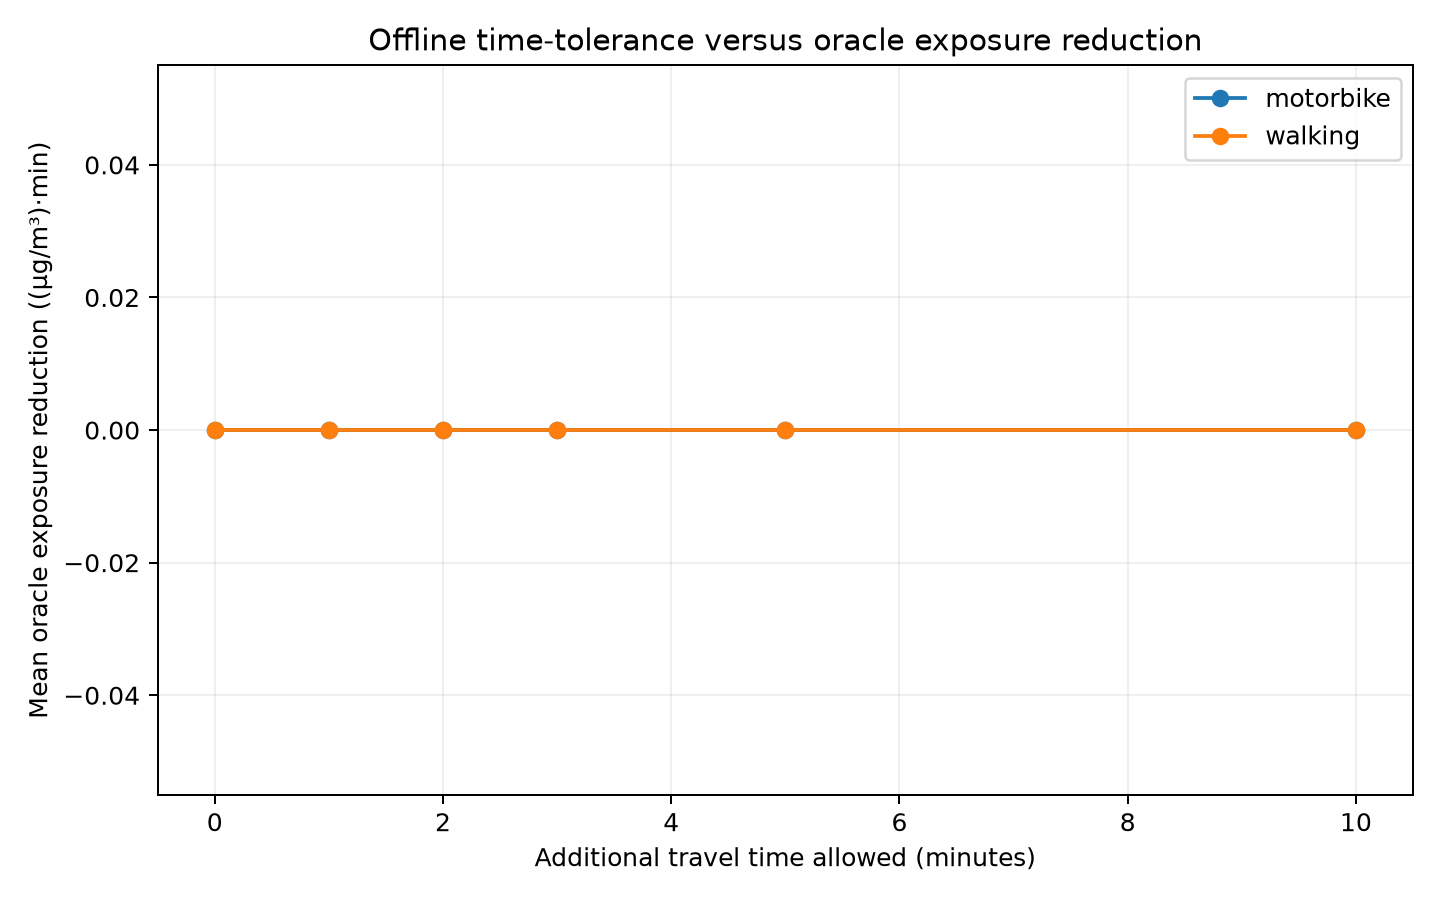

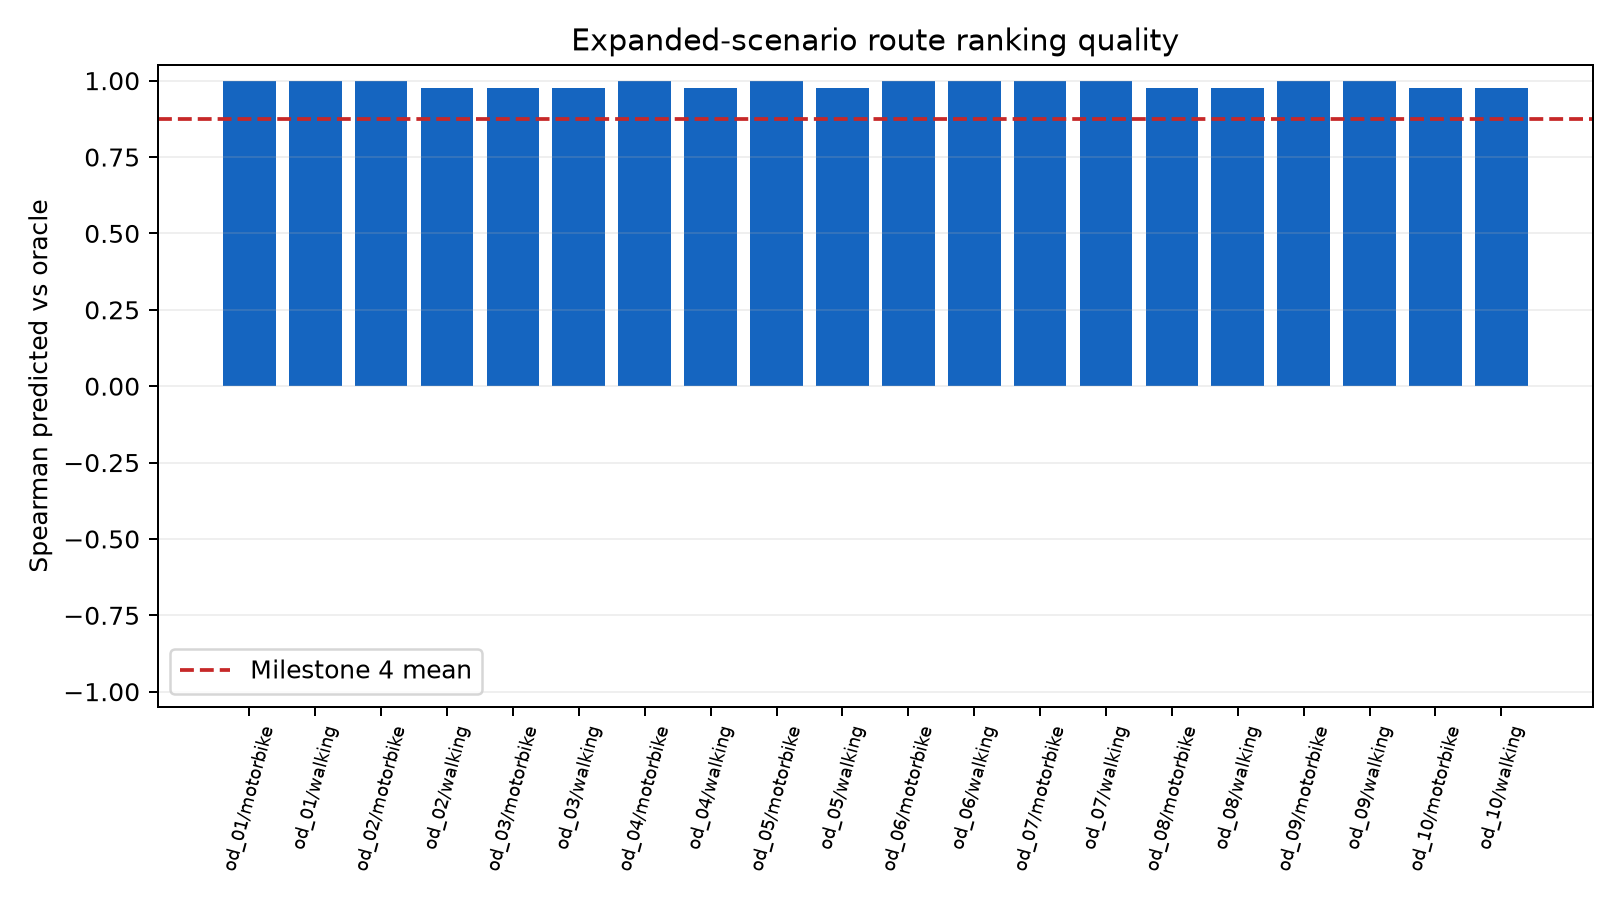

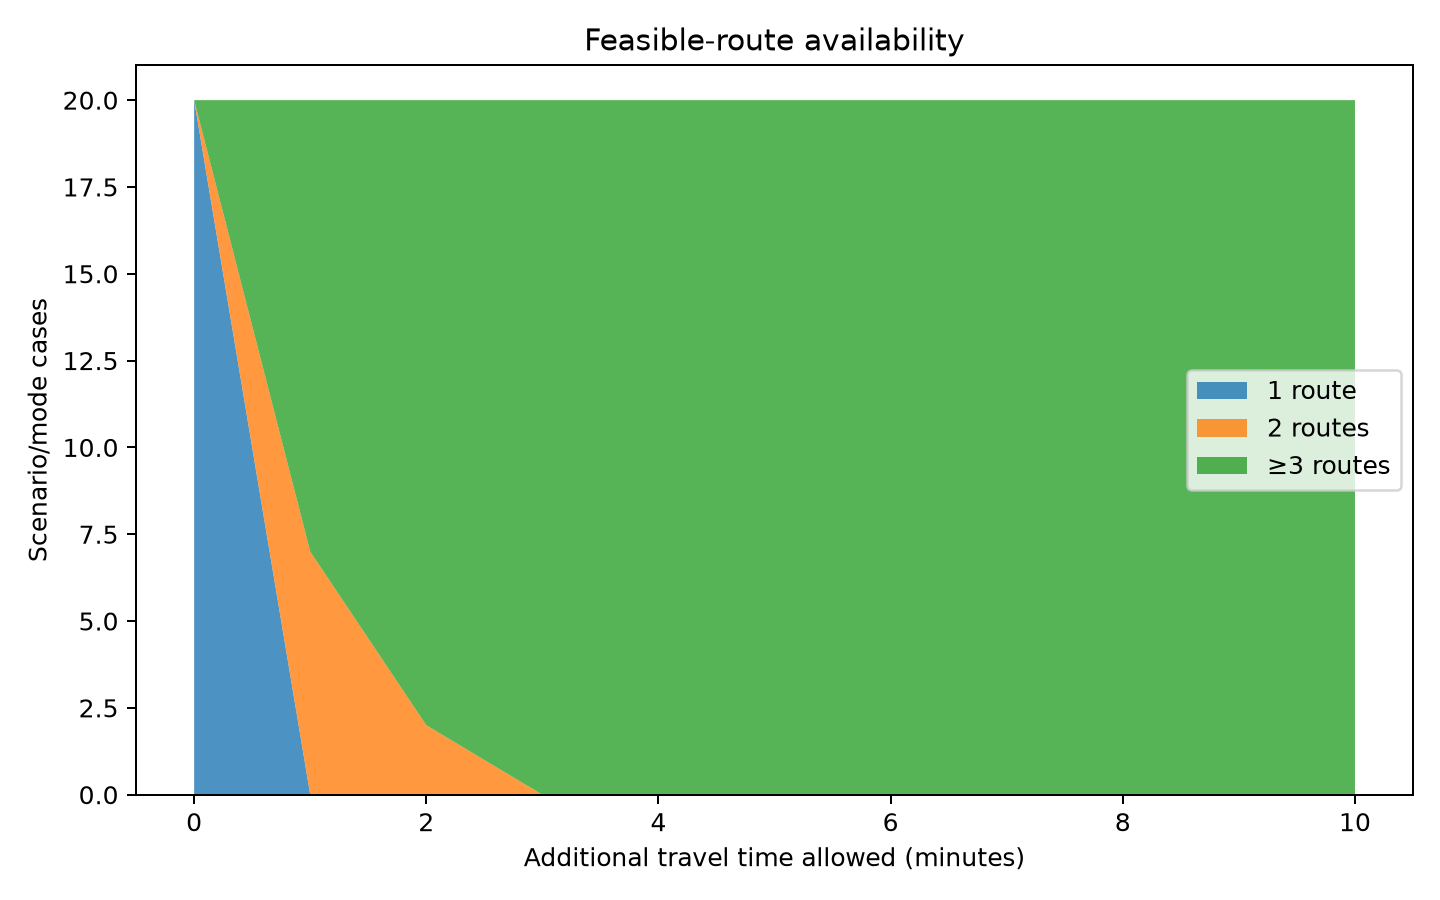

In [6]:
figure_dir = PROJECT_ROOT / "data/processed/optimization"
for name in (
    "time_exposure_tradeoff.png",
    "ranking_agreement.png",
    "feasible_route_availability.png",
):
    display(Image(filename=str(figure_dir / name)))